In [1]:
import os
import pickle
from pennylane import numpy as np
import pennylane as qml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import pandas as pd
import json
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras.callbacks import Callback
import time



## Configuration

In [2]:
DATA_PATH = "dataset/mirage2019_LOPEZ_lopez_lopez_36P_4F_APP_xST_PAD_metadata.pickle"
BATCH_SIZE = 50
EPOCHS = 100
LEARNING_RATE = 1e-3
PATIENCE = 5 # Early stopping patience
RANDOM_SEED = 2025

N_PACKETS = 10
N_FEATURES = 4

N_QUBITS = 5
N_LAYERS = 3

# Riproducibilità
np.random.seed(RANDOM_SEED)                    # NumPy
tf.random.set_seed(RANDOM_SEED)                # TensorFlow
tf.keras.utils.set_random_seed(RANDOM_SEED)    # Keras
random.seed(RANDOM_SEED)

## Load Data

In [3]:
print("Loading dataset...")
with open(DATA_PATH, "rb") as f:
    X_raw = np.array(pickle.load(f), dtype=np.float32) # Convert to numpy array
    y_raw = np.array(pickle.load(f)) # Convert to numpy array

print(f"Data shape: {X_raw.shape}")
print(f"Labels shape: {len(y_raw)}")

# Example sample
example_sample = 5000
print("\nExample Sample (First 5 packets):\n", X_raw[example_sample][:5])
print("Example Label:", y_raw[example_sample])

Loading dataset...
Data shape: (96999, 36, 4)
Labels shape: 96999

Example Sample (First 5 packets):
 [[0.00e+00 2.31e+02 3.43e+02 0.00e+00]
 [1.00e+00 1.52e+02 4.40e+02 0.00e+00]
 [0.00e+00 5.10e+01 3.47e+02 0.00e+00]
 [0.00e+00 1.46e+03 3.47e+02 0.00e+00]
 [0.00e+00 3.87e+02 3.47e+02 0.00e+00]]
Example Label: AccuWeather


## Label Encoding

In [4]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
NUM_CLASSES = len(le.classes_)
print(f"Number of classes: {NUM_CLASSES}")
print("Classes:", le.classes_)

Number of classes: 40
Classes: ['8 Ball Pool' 'AccuWeather' 'Amazon' 'Booking' 'Comics' 'Diretta'
 'Dropbox' 'Duolingo' 'Facebook' 'Flipboard' 'FourSquare' 'Google Drive'
 'Groupon' 'Hangouts' 'Instagram' 'Linkedin' 'Messenger' 'Musixmatch'
 'OneDrive' 'OneFootball' 'Pinterest' 'Playstore' 'Reddit' 'Skype'
 'Slither.io' 'SoundCloud' 'Spotify' 'Subito' 'Telegram' 'Trello'
 'TripAdvisor' 'Tumblr' 'Twitter' 'Uber' 'Viber' 'Waze' 'Wish' 'Youtube'
 'eBay' 'ilMeteo']


## Train-Validation-Test split

In [5]:
TRAIN_SIZE = 0.7
VAL_SIZE = 0.15
TEST_SIZE = 0.15

# Check if sizes sum to 1
assert TRAIN_SIZE + VAL_SIZE + TEST_SIZE == 1.0, "Train, Val, Test sizes must sum to 1."

# First split: 85% Train+Val, 15% Test
X_temp, X_test, y_temp, y_test = train_test_split(X_raw, y_encoded, test_size=TEST_SIZE, stratify=y_encoded, random_state=2025)

# Second split: Split the 85% into Train (70% total) and Val (15% total)
# 15 / 85 ~= 0.1765
tmp_size = VAL_SIZE / (TRAIN_SIZE + VAL_SIZE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=tmp_size, stratify=y_temp, random_state=2025)

# # For testing resize training to 1000 samples
# X_train = X_train[:1000]
# y_train = y_train[:1000]
# X_val = X_val[:500]
# y_val = y_val[:500]
# X_test = X_test[:500]
# y_test = y_test[:500]

print(f"Train shape: {X_train.shape} ({len(X_train)/len(X_raw):.1%})")
print(f"Val shape:   {X_val.shape}   ({len(X_val)/len(X_raw):.1%})")
print(f"Test shape:  {X_test.shape}  ({len(X_test)/len(X_raw):.1%})")

Train shape: (67899, 36, 4) (70.0%)
Val shape:   (14550, 36, 4)   (15.0%)
Test shape:  (14550, 36, 4)  (15.0%)


(Optional) Reduce Training set size

In [6]:
# New training size
NEW_TRAIN_SIZE = 50000
if len(X_train) > NEW_TRAIN_SIZE:
    percentage = NEW_TRAIN_SIZE / len(X_train)
    # train test spit to reduce training set size
    X_train, _, y_train, _ = train_test_split(X_train, y_train, train_size=percentage, stratify=y_train, random_state=2025)
    print(f"Reduced Train shape: {X_train.shape} ({len(X_train)/len(X_raw):.1%})")
else:
    print("Training set size is less than or equal to the new size. No reduction applied.")

Reduced Train shape: (50000, 36, 4) (51.5%)


## Preprocessing

In [7]:
def preprocess_data(X):
    """
    Handles padding and normalizes features.
    X shape: (N, 36, 4)
    Features: [DIR, PL, TCPWIN, IAT]
    """
    X_proc = X.copy().astype(np.float32)
    
    # Mask for padding (using PL at index 1)
    is_padding = (X_proc[:, :, 1] == -1)
    
    # Set all features to 0 where is_padding is True
    mask = np.repeat(is_padding[:, :, np.newaxis], 4, axis=2)
    X_proc[mask] = 0
    
    # Apply Log1p to PL (1), TCPWIN (2), IAT (3)
    X_proc[:, :, 1:] = np.log1p(np.maximum(X_proc[:, :, 1:], 0)) 
    
    return X_proc[:, :N_PACKETS, :]

print("Preprocessing data...")
X_train_proc = preprocess_data(X_train)
X_val_proc = preprocess_data(X_val)
X_test_proc = preprocess_data(X_test)

print("Preprocessing complete.")
print("Train shape:", X_train_proc.shape)
print("Val shape:", X_val_proc.shape)
print("Test shape:", X_test_proc.shape)

Preprocessing data...
Preprocessing complete.
Train shape: (50000, 10, 4)
Val shape: (14550, 10, 4)
Test shape: (14550, 10, 4)


One-Hot Encoding

In [8]:
y_train_ohe = tf.keras.utils.to_categorical(y_train, num_classes=40)
y_val_ohe = tf.keras.utils.to_categorical(y_val, num_classes=40)
y_test_ohe = tf.keras.utils.to_categorical(y_test, num_classes=40) 

print("Y Train shape: ", y_train_ohe.shape)
print("Y Val shape: ", y_val_ohe.shape)
print("Y Test shape: ", y_test_ohe.shape)

Y Train shape:  (50000, 40)
Y Val shape:  (14550, 40)
Y Test shape:  (14550, 40)


## Quantum Circuit

In [9]:

# Definizione del circuito quantistico
# max_workers = os.cpu_count()
# print(f"Using {max_workers} CPU cores for PennyLane.")
dev = qml.device("default.qubit", wires=N_QUBITS, seed=RANDOM_SEED)

@qml.qnode(dev , interface="tf", diff_method="backprop")
def qnode(inputs, weights):
    
    # Feature map
    qml.AmplitudeEmbedding(inputs, wires=range(N_QUBITS), normalize=True, pad_with=0.0)

    # Ansatz
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))

    # Processo di misurazione
    return qml.probs(wires=range(N_QUBITS))

# Pesi dell'ansatz
weights = np.random.rand(N_LAYERS*N_QUBITS*3).reshape(N_LAYERS,N_QUBITS,3)
weights = tf.Variable(weights, dtype=tf.float64, trainable=True)
weight_shapes = {"weights": (N_LAYERS,N_QUBITS,3)}


## Sequential Model

In [10]:

#Definizione del modello
model = Sequential(name='ampe_fixed_probs')
model.add(Flatten(input_shape=(N_PACKETS, N_FEATURES)))
model.add(Dense(2**N_QUBITS,activation='sigmoid', input_dim=N_PACKETS*N_FEATURES))
model.add(qml.qnn.KerasLayer(qnode, weight_shapes, output_dim=2**N_QUBITS)) # <-- qui c'è la parte quantum
model.add(Dense(NUM_CLASSES, activation='softmax'))
model.build(np.shape(X_train))

## Training

In [11]:
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
earlystop = EarlyStopping(monitor='val_accuracy', min_delta=0, patience=PATIENCE, verbose=1, mode='auto')
# Timeout callback
class TimeoutCallback(Callback):
    """Interrompe l'addestramento dopo un certo numero di minuti."""
    def __init__(self, minutes=22):
        super(TimeoutCallback, self).__init__()
        self.timeout_minutes = minutes
        self.start_time = None

    def on_train_begin(self, logs=None):
        # Registra il tempo di inizio quando l'addestramento comincia
        self.start_time = time.time()
        print(f"\n[INFO] Addestramento iniziato. Tempo limite: {self.timeout_minutes} minuti.")

    def on_epoch_end(self, epoch, logs=None):
        elapsed_time = time.time() - self.start_time
        elapsed_minutes = elapsed_time / 60.0

        # Controlla se il tempo trascorso supera il limite
        if elapsed_minutes >= self.timeout_minutes:
            print(f"\n[TIMEOUT] Addestramento interrotto dopo {elapsed_minutes:.2f} minuti (Limite: {self.timeout_minutes} min).")
            # Imposta 'model.stop_training' a True per interrompere
            self.model.stop_training = True

timeout_callback = TimeoutCallback(minutes=22)
callbacks = [earlystop, timeout_callback]

history = model.fit(X_train_proc, y_train_ohe, validation_data=(X_val_proc,y_val_ohe),
                epochs=EPOCHS, batch_size=BATCH_SIZE,
                callbacks=callbacks, verbose=2)


[INFO] Addestramento iniziato. Tempo limite: 22 minuti.
Epoch 1/100
1000/1000 - 103s - loss: 3.3962 - accuracy: 0.1316 - val_loss: 3.1900 - val_accuracy: 0.1735 - 103s/epoch - 103ms/step
Epoch 2/100
1000/1000 - 101s - loss: 3.0702 - accuracy: 0.1972 - val_loss: 2.9691 - val_accuracy: 0.2184 - 101s/epoch - 101ms/step
Epoch 3/100
1000/1000 - 100s - loss: 2.9034 - accuracy: 0.2279 - val_loss: 2.8442 - val_accuracy: 0.2348 - 100s/epoch - 100ms/step
Epoch 4/100
1000/1000 - 101s - loss: 2.8007 - accuracy: 0.2394 - val_loss: 2.7615 - val_accuracy: 0.2409 - 101s/epoch - 101ms/step
Epoch 5/100
1000/1000 - 101s - loss: 2.7309 - accuracy: 0.2475 - val_loss: 2.7064 - val_accuracy: 0.2533 - 101s/epoch - 101ms/step
Epoch 6/100
1000/1000 - 101s - loss: 2.6799 - accuracy: 0.2608 - val_loss: 2.6624 - val_accuracy: 0.2598 - 101s/epoch - 101ms/step
Epoch 7/100
1000/1000 - 100s - loss: 2.6402 - accuracy: 0.2747 - val_loss: 2.6271 - val_accuracy: 0.2914 - 100s/epoch - 100ms/step
Epoch 8/100
1000/1000 - 10

Saving Results

In [12]:
# Saving results
model_name = "14E_50B_50k"
output_dir = "./quantum_models"

os.makedirs(f"{output_dir}", exist_ok=True)
os.makedirs(f"{output_dir}/{model_name}", exist_ok=True)

with open(f"{output_dir}/{model_name}/model_summary.txt", "w") as f:
    model.summary(print_fn=lambda x: f.write(x + "\n"))

df_history = pd.DataFrame(history.history)
df_history.to_csv(f"{output_dir}/{model_name}/training_history.csv", index=False)

model.save(f"{output_dir}/{model_name}/model.h5")

## Testing and Evaluation

(Optnional) Load Model

In [ ]:
#loading model from file
def load_keras_quantum_layer(*args, **kwargs):
    allowed = ["output_dim", "name", "trainable", "dtype"]
    filtered_kwargs = {k: v for k, v in kwargs.items() if k in allowed}
    return qml.qnn.KerasLayer(qnode, weight_shapes, **filtered_kwargs)

# model_name = "10E_50B_10P"
# output_dir = "./quantum_models"
model = tf.keras.models.load_model(
    f"{output_dir}/{model_name}/model.h5",
    custom_objects={'KerasLayer': load_keras_quantum_layer}
)
# Load training history from csv
df_history = pd.read_csv(f"{output_dir}/{model_name}/training_history.csv")
history = tf.keras.callbacks.History()
history.history = df_history.to_dict(orient='list')


Testing set loss and accuracy

In [13]:
loss, accuracy = model.evaluate(X_test_proc, y_test_ohe)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


455/455 [==============================] - 16s 36ms/step - loss: 2.4617 - accuracy: 0.3231
Test Loss: 2.4617
Test Accuracy: 0.3231


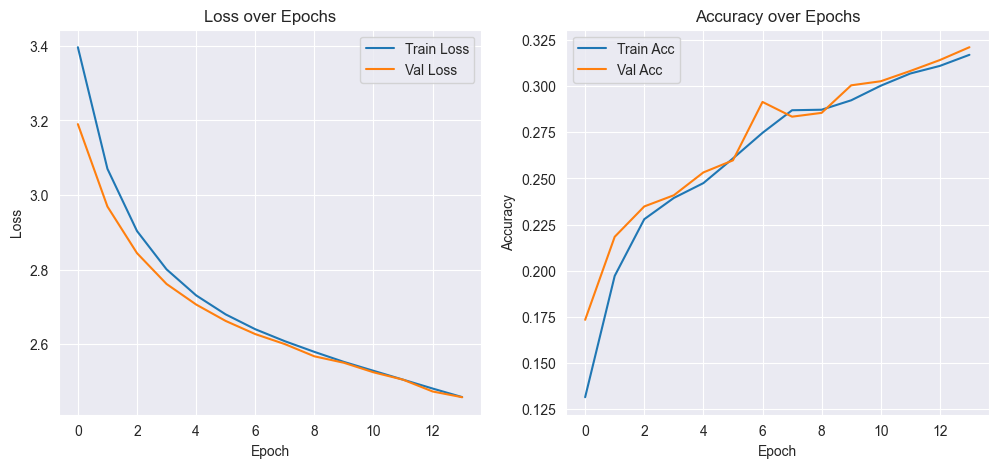

In [14]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, label='Train Acc')
plt.plot(epochs_range, val_acc, label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy') # Tolto (%) perché TF solitamente usa 0-1
plt.legend()

plt.show()

455/455 [==============================] - 16s 35ms/step


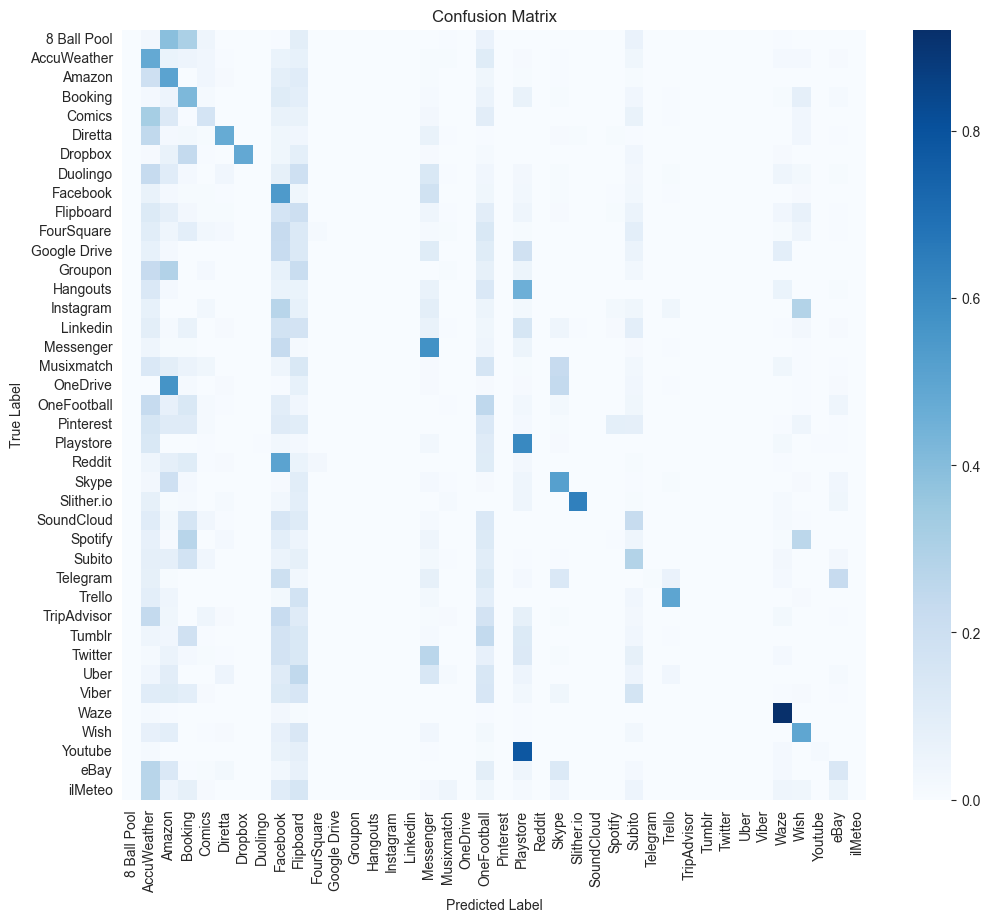

In [15]:
labels = np.arange(len(le.classes_))
y_pred = np.argmax(model.predict(X_test_proc), axis=1)


cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels,        # forza ordine e numero delle classi
    normalize='true'
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=False,
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

In [16]:

print("Classi del LabelEncoder:", len(le.classes_))
print("Valori unici y_test:", np.unique(y_test))
print("Valori unici y_pred:", np.unique(y_pred))

Classi del LabelEncoder: 40
Valori unici y_test: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
Valori unici y_pred: [ 0  1  2  3  4  5  6  7  8  9 10 16 17 19 21 23 24 26 27 28 29 35 36 37
 38]


In [17]:

# --- 3. Classification Report ---
print("Classification Report:")
report_dict = classification_report(y_test, y_pred, target_names=le.classes_, labels=np.arange(40), digits=4, zero_division=0)
print(report_dict)

Classification Report:
              precision    recall  f1-score   support

 8 Ball Pool     0.0000    0.0000    0.0000       192
 AccuWeather     0.2148    0.4822    0.2972       898
      Amazon     0.1280    0.5074    0.2044       272
     Booking     0.2165    0.4193    0.2855       477
      Comics     0.2579    0.1641    0.2006       396
     Diretta     0.7522    0.4749    0.5822       537
     Dropbox     0.9888    0.4835    0.6494       182
    Duolingo     0.0000    0.0000    0.0000       399
    Facebook     0.3229    0.5402    0.4042      1244
   Flipboard     0.1296    0.1997    0.1572       776
  FourSquare     0.5000    0.0173    0.0335       346
Google Drive     0.0000    0.0000    0.0000        54
     Groupon     0.0000    0.0000    0.0000        97
    Hangouts     0.0000    0.0000    0.0000       103
   Instagram     0.0000    0.0000    0.0000       136
    Linkedin     0.0000    0.0000    0.0000       177
   Messenger     0.5424    0.5732    0.5574      1216
  Mu

In [18]:
# Salva classification report su file
with open(f"{output_dir}/{model_name}/classification_report.txt", "w") as f:
    f.write(report_dict)
